# Fraud Detection using Machine Learning

## Project Overview

Financial fraud is a major challenge for banks and payment platforms where large volumes of transactions need to be monitored for potentially suspicious activity. Manually reviewing every transaction is not practical, so a suitable machine learning algorithm can be used to identify transactions that may require further investigation to detect potential frauds.

In this project, I built an end-to-end fraud detection system using transaction and account balance information. The workflow covers data exploration, feature engineering, model development, evaluation, and model explainability using SHAP.

The final XGBoost model is trained and integrated into a Streamlit web application where users can enter transaction details and receive a fraud prediction, probability, risk level, and an explanation of the factors influencing the prediction. An AI assistant is also used to turn the model's SHAP results into a short explanation.

# 1. Import Required Libraries


In [ ]:
# Numerical computing and Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Data preprocessing
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Machine Learning Models
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, r2_score, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score


# Model Explainability
import shap

# Model saving
import joblib as jl

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline

# 2. Load the Dataset

In [2]:
df=pd.read_csv("../data/raw_data/Fraud-detection-dataset.csv")
df.head() # Display the first five rows

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# 3. Initial Data Inspection and Data Cleaning

Before preparing the data, I first checked its structure, data types, missing values, duplicate values and class distribution.

In [3]:
df.info() # Display the summary of the dataset


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [4]:
df.isnull().sum() # Check for missing values in the dataset


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
df.describe() # Display the statistical summary of the dataset

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.duplicated().sum() # Check for duplicate rows in the dataset

np.int64(0)

In [7]:
df['type'].value_counts() # Display the count of each transaction type  


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [8]:
df['isFraud'].value_counts(normalize=True)*100 # Display the count of fraudulent and non-fraudulent transactions as percentages

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

Fraud detection datasets are typically highly imbalanced with legitimate transactions count way greater than the fraudulent ones. Checking this distribution is important because accuracy alone can give a misleading view of model performance. Here, 99.87% of the transactions are legitimate while only 0.13% of the transactions are actually fraudulent. This shows that dataset is highly imbalanced and we need to take appropriate measures to deal with this so our model is not biased or favor the majority class.

# 4. Exploratory Data Analysis (EDA)
The following analysis focuses on understanding the distribution of the target variable(isFraud), feature relationships, and business insights that can guide feature engineering and model development.

## Fraud vs Non-Fraud Transactions


Text(0, 0.5, 'Number of Transactions')

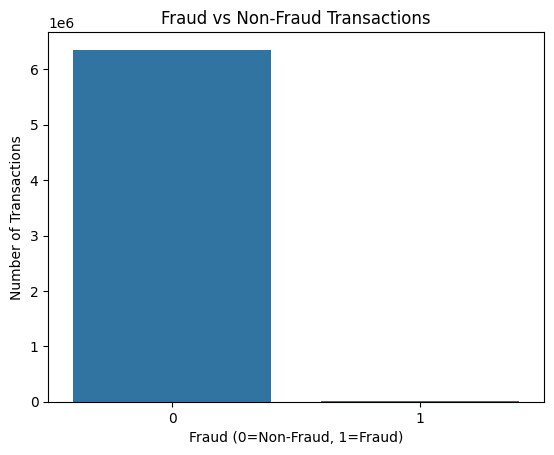

In [9]:
sns.countplot(x='isFraud', data=df) # Visualize the distribution of transaction types and their corresponding fraud status
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud (0=Non-Fraud, 1=Fraud)')
plt.ylabel('Number of Transactions')

The distribution clearly shows how heavily the dataset is dominated by legitimate transactions while fraudulent transactions represent only a very small fraction of the total.

## Transaction Amount by Fraud Status

In [10]:
df.groupby('isFraud')['amount'].describe()  # Display the count of fraudulent and non-fraudulent transactions

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Fraudulent transactions have a higher average transaction amount than legitimate transactions.

## Fraud Distribution Across Transaction Types

In [11]:
pd.crosstab(df['type'], df['isFraud'], normalize='index')*100   # Display the proportion of fraudulent transactions for each transaction type 

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


The table shows that fraudulent transactions are concentrated in specific transaction types, particularly CASH_OUT and TRANSFER

Text(0, 0.5, 'Number of Transactions')

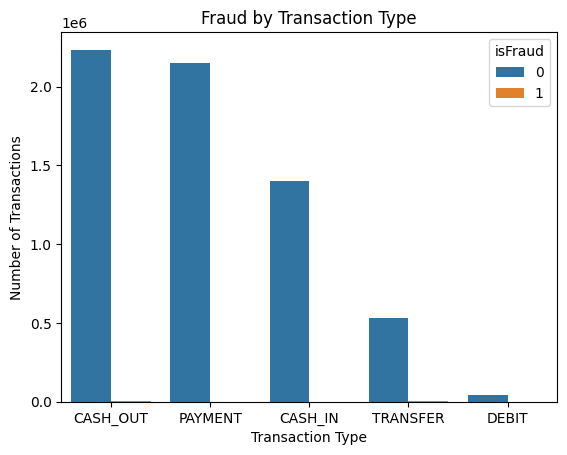

In [12]:
order=df['type'].value_counts().index  # Get the order of transaction types based on their counts   
sns.countplot(x='type', hue='isFraud', data=df, order=order) # Visualize the distribution of transaction types and their corresponding fraud status
plt.title('Fraud by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')    

## Fraud Rate by Transaction Type

Text(0, 0.5, 'Fraud Rate')

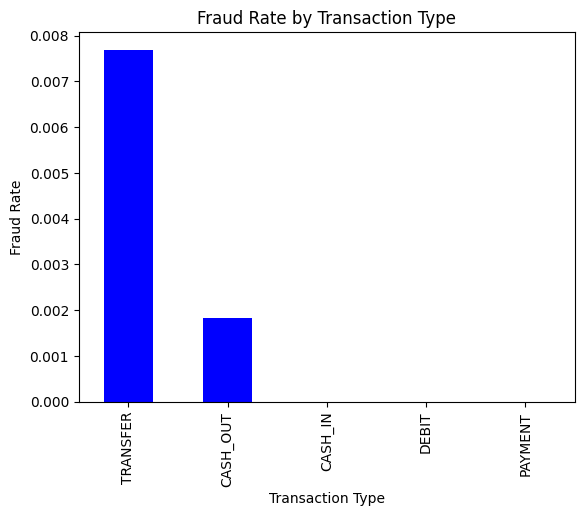

In [13]:
fraud_rate=df.groupby('type')['isFraud'].mean().sort_values(ascending=False) # Calculate the fraud rate for each transaction type
fraud_rate.plot(kind='bar', color='blue') # Visualize the fraud rate for each transaction type
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')  
plt.ylabel('Fraud Rate')

The fraud rate is highest for TRANSFER transactions, followed by CASH_OUT and very little to negligible for other remaining types. This suggests that Transaction Type is one of the important feature.

## Transaction Amount Distribution

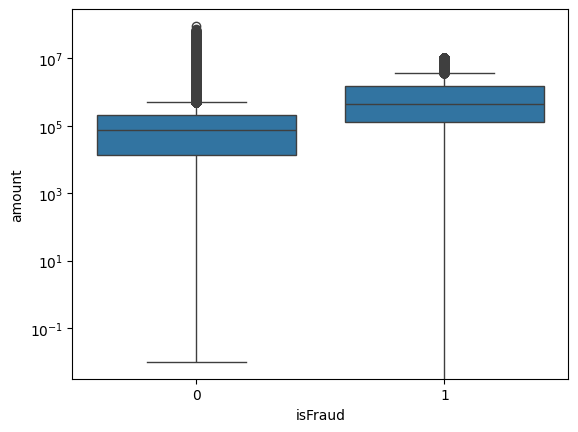

In [14]:
sns.boxplot(x='isFraud', y='amount', data=df) # Visualize the distribution of transaction amounts for fraudulent and non-fraudulent transactions
plt.yscale('log') # Set the y-axis to a logarithmic scale for better visualization

Using a logarithmic scale makes the distribution easier to compare. Fraudulent transactions appear to have a higher typical transaction amount.

## Fraud Over Time

Text(0, 0.5, 'Fraud Count')

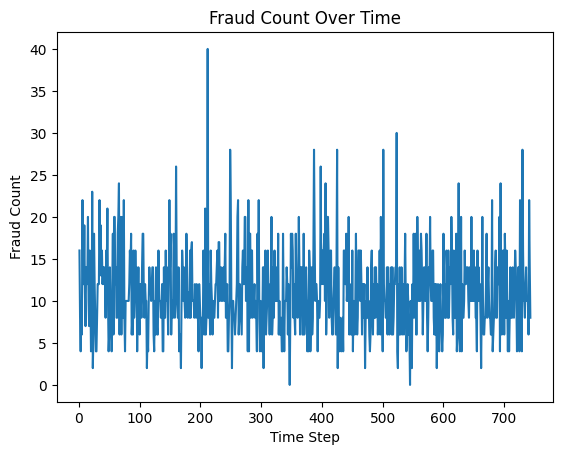

In [15]:
fraud_over_time=df.groupby('step')['isFraud'].sum() # Calculate the fraud count over time
plt.plot(fraud_over_time)
plt.title('Fraud Count Over Time')
plt.xlabel('Time Step')
plt.ylabel('Fraud Count')

Although we see certain spikes but it doesn't seem like there is any clear relation between fraud counts and time steps.

## Balance Change Features

In [16]:
df['OrigBalanceChange']=df['oldbalanceOrg']-df['newbalanceOrig'] # Calculate the change in original balance
df['DestBalanceChange']=df['oldbalanceDest']-df['newbalanceDest'] # Calculate the change in destination balance

## Feature Correlation Analysis

<Axes: >

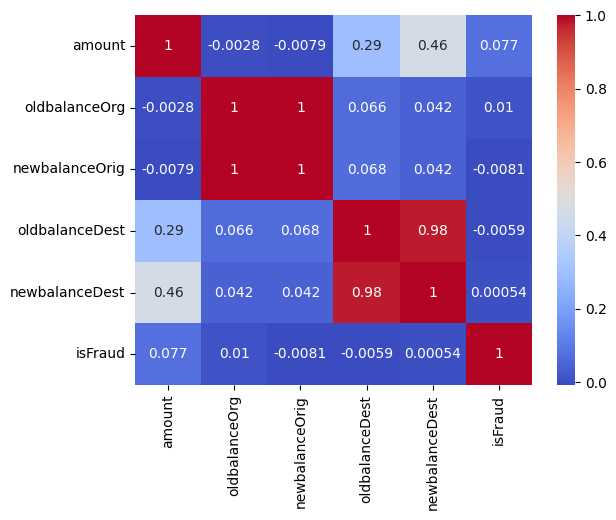

In [18]:
corr=df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm') # Visualize the correlation between features and the target variable

The correlation matrix helps identify relationships between the numerical features and the fraud target.

The strongest relationships are between the original and new account balances. The correlation with the fraud label is relatively weak for most individual numerical features. This suggests that fraud detection is likely to depend on many features together.

In [19]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,OrigBalanceChange,DestBalanceChange
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


## Final Feature Selection

After exploring the data and identifying the features most relevant to fraud detection, final dataframe is prepared. 
The **nameOrig** (identifier), **step** (time step), and the pre-existing fraud flag (**isFlaggedFraud**) were removed because they do not provide useful information for the modelling.

In [20]:
new_df=df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud', 'step'], axis=1) 
new_df.head() # Display the first five rows of the new dataframe after dropping unnecessary columns

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,OrigBalanceChange,DestBalanceChange
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


# 5. Data Preparation for Machine Learning

### Identify feature types so each can be processed appropriately.

In [26]:
categorical_features = ['type'] # List of categorical features
numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'OrigBalanceChange', 'DestBalanceChange'] # List of numerical features

In [22]:
X=new_df.drop('isFraud', axis=1) # Features
y=new_df['isFraud'] # Target variable

### Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Split the dataset into training and testing sets

### Preprocessing Pipeline

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(), numerical_features),
        ('cat',OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# 6. Model Training & Evaluation

To identify the most effective classifier for fraud detection, multiple machine learning algorithms were trained and evaluated. Each model was combined with the preprocessing pipeline and hyperparameters were optimized using GridSearchCV with 5-fold cross-validation.

Since fraud detection dataset is highly imbalanced, where fraudulent transactions represent only a very small portion of the dataset. Because of this, relying on accuracy alone could be misleading as a model could achieve high accuracy simply by predicting most transactions as legitimate. 

To handle the class imbalance, class weighting was used where supported, giving greater importance to fraudulent transactions during training. The train-test split was also performed using stratification, ensuring that the minority fraud class remained represented in both sets.

## Logistic Model Pipeline

Logistic Regression is used as the baseline classification model. To address the highly imbalanced fraud dataset, **class_weight='balanced'** is used to give greater weight to fraudulent transactions during training.

In [29]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ]
)

In [30]:
logistic_model.fit(X_train, y_train) # Fit the logistic regression model to the training data

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['type','amount','oldbalanceOrg',...,'newbalanceDest','OrigBalanceChange', 'DestBalanceChange']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

### Confusion Matrix Function

In [35]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, fmt='d'); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['legit', 'fraud']); ax.yaxis.set_ticklabels(['legit', 'fraud']) 
    plt.show() 

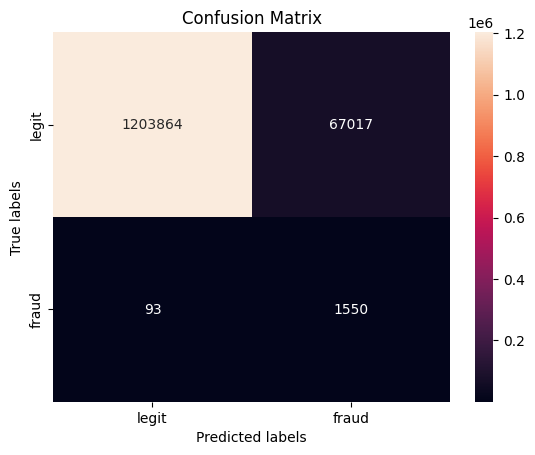

Classification report for logistic regression :
               precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524

ROC-AUC : 0.9453317578996938


In [36]:
yhat_1 = logistic_model.predict(X_test) # Make predictions on the test set

#Model evaluation
plot_confusion_matrix(y_test,yhat_1)
print("Classification report for logistic regression :\n", classification_report(y_test, yhat_1)) 
print("ROC-AUC :", roc_auc_score(y_test,yhat_1))



## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce the risk of relying on a single tree. **class_weight='balanced'** was used to give greater importance to the minority fraud class.

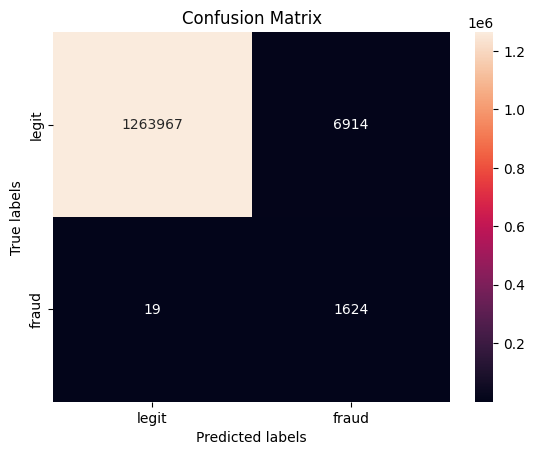

Classification report for random forest :
               precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.19      0.99      0.32      1643

    accuracy                           0.99   1272524
   macro avg       0.60      0.99      0.66   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC-AUC : 0.99149773382939


In [37]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)
rf_model.fit(X_train, y_train)

yhat_2= rf_model.predict(X_test)

#Model evaluation
plot_confusion_matrix(y_test,yhat_2)
print("Classification report for random forest :\n", classification_report(y_test, yhat_2)) 
print("ROC-AUC :", roc_auc_score(y_test,yhat_2))



## XGBoost Classifier
XGBoost is a gradient-boosting ensemble algorithm that builds decision trees sequentially, with each new tree improving upon the errors of the previous ones. XGBoost uses **scale_pos_weight** to assign greater importance to the minority fraud class during training.
The weight is calculated as the ratio of legitimate transactions to fraudulent transactions in the training data:
scale_pos_weight = number of legitimate transactions / number of fraudulent transactions

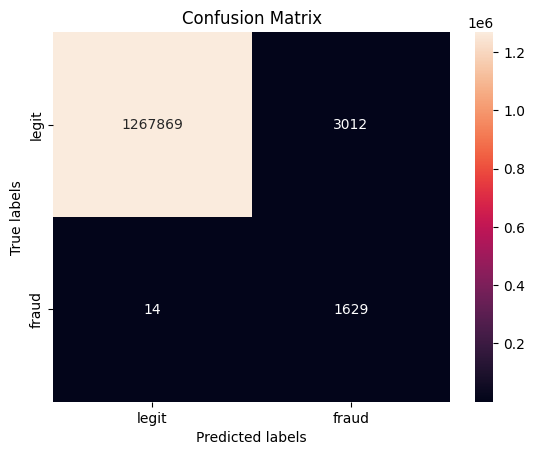

Classification report for XGBoost :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.35      0.99      0.52      1643

    accuracy                           1.00   1272524
   macro avg       0.68      0.99      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9945544961800269


In [40]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            scale_pos_weight=scale_pos_weight,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ]
)
xgb_model.fit(X_train, y_train)

yhat_3 = xgb_model.predict(X_test)

#Model evaluation
plot_confusion_matrix(y_test,yhat_3)
print("Classification report for XGBoost :\n", classification_report(y_test, yhat_3)) 
print("ROC-AUC :", roc_auc_score(y_test,yhat_3))

## Decision Tree Classifier
Decision Tree provides a simple rule-based approach to fraud classification by recursively splitting transactions according to their feature values. class_weight='balanced' was applied to give greater importance to fraudulent transactions during training.

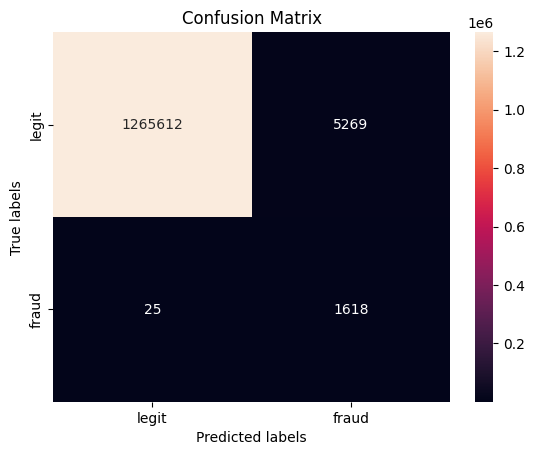

Classification report for Decision Tree :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.23      0.98      0.38      1643

    accuracy                           1.00   1272524
   macro avg       0.62      0.99      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9903189944890995


In [41]:
dt_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=12,
            class_weight='balanced',
            random_state=42
        ))
    ]
)
dt_model.fit(X_train, y_train)
yhat_4 = dt_model.predict(X_test)

#Model evaluation
plot_confusion_matrix(y_test,yhat_4)
print("Classification report for Decision Tree :\n", classification_report(y_test, yhat_4)) 
print("ROC-AUC :", roc_auc_score(y_test,yhat_4))

# 7. Model Performance Comparison

The trained models were compared using accuracy, precision, recall, F1-score, and ROC-AUC. Since the dataset is highly imbalanced, ROC-AUC, precision, recall, and F1-score provide more meaningful comparisons than accuracy alone.

In [42]:
results = []
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)


comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.9976,0.3510,0.9915,0.5185,0.9995
2,Random Forest,0.9946,0.1902,0.9884,0.3190,0.9992
1,Decision Tree,0.9958,0.2349,0.9848,0.3794,0.9919
0,Logistic Regression,0.9473,0.0226,0.9434,0.0442,0.9898


# 8. Final Model Selection

Based on the evaluation results, XGBoost achieved the strongest overall performance, particularly in highest **ROC-AUC (0.9995)** and highest **F1-score (0.5185)** with greater **recall (0.9915)**. It was therefore selected as the final model for fraud detection.

# 9. Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) was used to understand how individual features influence the model's fraud predictions.

In [ ]:

preprocessor_fitted = xgb_model.named_steps['preprocessor']
best_xgb = xgb_model.named_steps['model']

In [56]:
x_shap = X_test.sample(2000, random_state=42)
x_shap_transformed = preprocessor_fitted.transform(x_shap)

feature_names = preprocessor_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(x_shap_transformed)

shap_values.feature_names = feature_names

## Global Feature Importance using SHAP

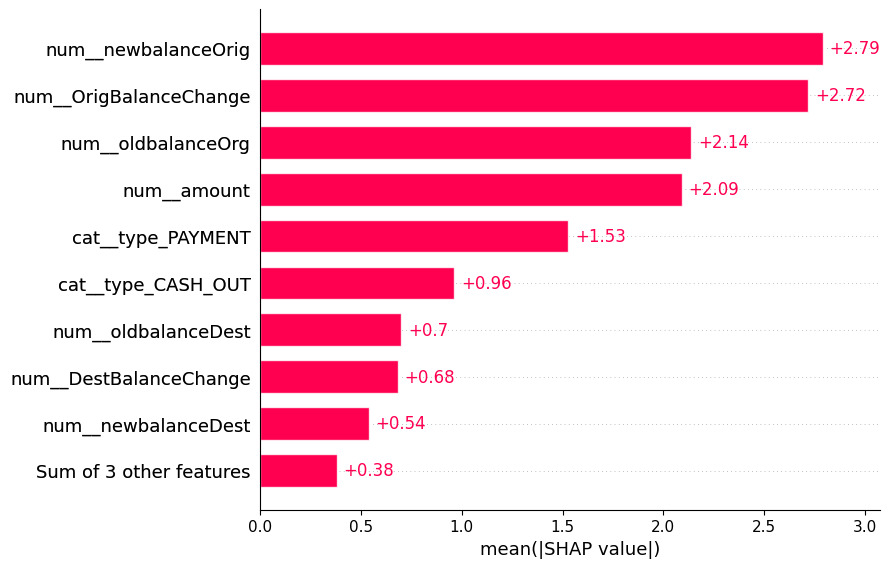

In [ ]:
# Global importance
shap.plots.bar(shap_values)

### Interpretation
The global SHAP feature-importance plot ranks features according to their average impact on the XGBoost model's fraud predictions across the analyzed transactions. A larger mean absolute SHAP value indicates that the feature has a greater influence on the model's decisions.

Key observations:
- New origin-account balance has the strongest overall influence on fraud prediction.
- Origin account balance change and old origin-account balance are also major predictors.
- Transaction amount has a strong influence on the model's fraud predictions.
- Transaction type, particularly **PAYMENT** and **CASH_OUT**, contributes significantly to the model's decisions.

These findings suggest that the model relies heavily on account balance patterns, transaction amount, transaction type, and changes in account balances when identifying potentially fraudulent activity.

## SHAP Summary Plot

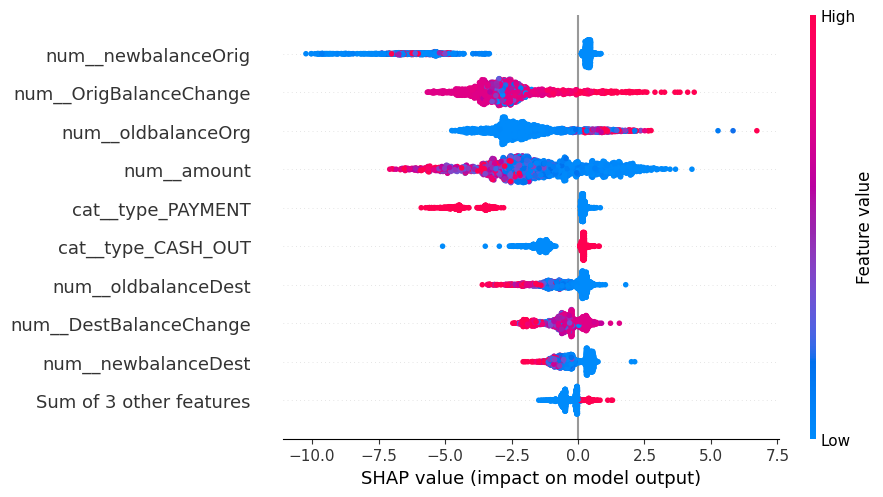

In [ ]:
# Beeswarm
shap.plots.beeswarm(shap_values)

## SHAP Waterfall Plot for an Individual Prediction

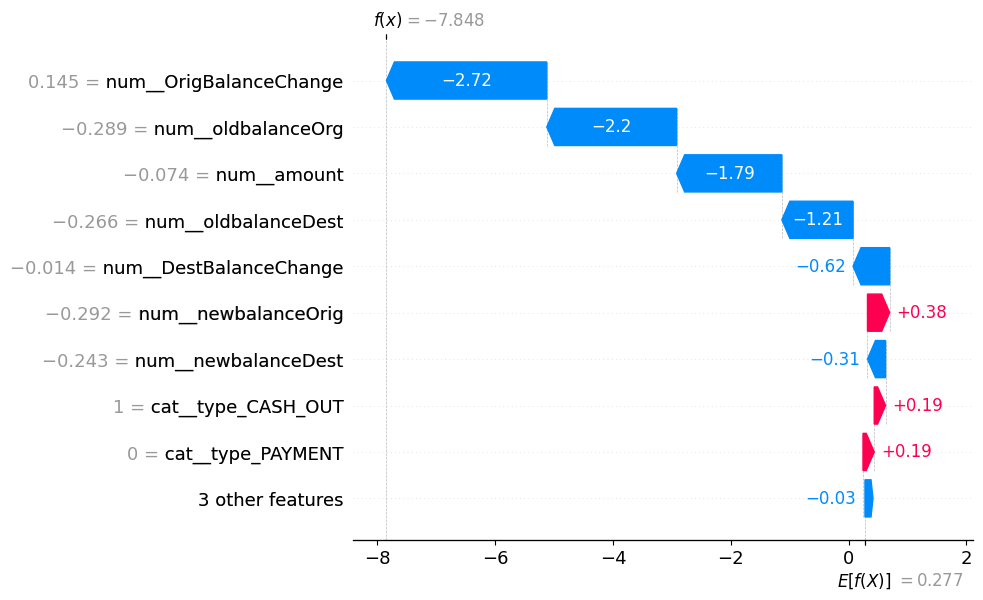

In [ ]:
# Waterfall
shap.plots.waterfall(shap_values[0])

### Interpretation

The SHAP waterfall plot explains why the model made a prediction for one specific transaction. Unlike the global SHAP plot, which summarizes the entire dataset, the waterfall shows how each feature moved this particular prediction toward or away from the fraud class.

For this transaction, the model output is f(x) = -7.848, indicating that the combined feature contributions pushed the prediction strongly toward the legitimate class.

Key observations:
- Origin balance change had the strongest negative contribution (−2.72), substantially reducing the model's fraud score.
- origin-account old balance further reduced the fraud score (−2.20).
- Transaction amount also pushed the prediction away from fraud (−1.79).
- New origin balance contributed slightly toward fraud (+0.38)

The model classified this transaction as legitimate because the strongest account-balance and transaction-related factors collectively reduced its fraud risk. Although some features pushed slightly toward fraud, their influence was considerably smaller than the factors pushing the prediction toward legitimate.

# 10. Saving the Model

In [60]:
from pathlib import Path

MODEL_DIR =Path("../model")

jl.dump(xgb_model, MODEL_DIR / "fraud_detection_model.pkl")


['..\\model\\fraud_detection_model.pkl']